##📘 SECTION 1: Setup & Imports


# 🍽️ ChefLink Campaign Success Prediction

## 📌 Project Overview

This notebook builds a classification model to predict whether a promotional
campaign for **ChefLink** (a food delivery service) will be **Successful**
or **Not Successful**.

**Client Brief:**  
Predict campaign success based on operational data (orders, revenue, new customers,
city, promo type, etc.). The dataset contains intentional data quality issues that
require thorough cleaning and standardization before modeling.

---

## 🗂️ Notebook Structure

| Section | Phase | Goal |
|---------|-------|------|
| 1 | Setup & Imports | Load required libraries |
| 2 | Load Data | Read dataset & first inspection |
| 3 | Data Quality Assessment | Identify problems in the raw data |
| 4 | Data Cleaning & Standardization | Fix all data quality issues |
| 5 | Target Definition | Define what "Successful" means |
| 6 | Feature Engineering | Build features for the model |
| 7 | Model Training & Evaluation | Train and evaluate classification models |
| 8 | Feature Importance & Insights | Business takeaways |

---

# 📦 SECTION 1: Setup & Imports

This section loads all required Python libraries:
- **pandas, numpy** — data manipulation
- **matplotlib, seaborn** — visualization
- **scikit-learn** — machine learning models & utilities
- **xgboost** — gradient boosting classifier

💻 Cell 1.2 — Code Cell



In [34]:
# ============================================================
# SECTION 1: Setup & Imports
# ------------------------------------------------------------
# Load all libraries needed throughout the notebook.
# Configure display settings and plot style for consistency.
# ============================================================

# --- Core data libraries ---
import pandas as pd
import numpy as np

# --- Visualization libraries ---
import matplotlib.pyplot as plt
import seaborn as sns

# --- Utilities ---
import warnings
warnings.filterwarnings("ignore")

# --- Display settings ---
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

# --- Plot styling ---
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"]  = (10, 5)
plt.rcParams["axes.titlesize"]  = 13
plt.rcParams["axes.labelsize"]  = 11

print("✅ All libraries imported successfully.")
print(f"   pandas version : {pd.__version__}")
print(f"   numpy version  : {np.__version__}")

✅ All libraries imported successfully.
   pandas version : 2.2.2
   numpy version  : 2.0.2


##📘 SECTION 2: Load Data & First Look

---

# 📂 SECTION 2: Load Data & First Look

## 📌 What This Section Does

In this section we will:

1. **Upload the raw dataset** to the Colab environment
2. **Load the data** into a pandas DataFrame
3. **Inspect the structure** — shape, column names, data types
4. **View sample rows** to understand what we're working with

> 💡 **Note for the client:**  
> The dataset is intentionally messy. The goal of this section is just to *load*
> the data and get a first impression — we will identify and fix all data quality
> issues in **Section 3** and **Section 4**.

---

## 📤 Step 2.1 — Upload the Dataset

Run the cell below and select the dataset file (CSV or Excel) from your computer
when the upload dialog appears.

💻 Cell 2.2 — Code Cell (Upload File)

In [35]:
# ============================================================
# SECTION 2.1: Upload the dataset file
# ------------------------------------------------------------
# A file picker dialog will appear — select the campaign dataset
# from your local computer (CSV or Excel format supported).
# ============================================================

from google.colab import files

print("📤 Please select the dataset file to upload...")
uploaded  = files.upload()
file_name = list(uploaded.keys())[0]
print(f"\n✅ File uploaded successfully: {file_name}")

📤 Please select the dataset file to upload...


Saving tzaio645zCvqEaFPn1sGsqIXaadpmDKo.xlsx to tzaio645zCvqEaFPn1sGsqIXaadpmDKo (1).xlsx

✅ File uploaded successfully: tzaio645zCvqEaFPn1sGsqIXaadpmDKo (1).xlsx


💻 Cell 2.3 — Code Cell (Load DataFrame)

In [36]:
# ============================================================
# SECTION 2.2: Load the dataset into a pandas DataFrame
# ------------------------------------------------------------
# Automatically detect file format (CSV or Excel) and read it.
# The DataFrame `df` will be used throughout the notebook.
# ============================================================

if file_name.endswith(".csv"):
    df = pd.read_csv(file_name)
elif file_name.endswith((".xlsx", ".xls")):
    df = pd.read_excel(file_name)
else:
    raise ValueError(f"Unsupported file format: {file_name}")

print(f"✅ Dataset loaded successfully")
print(f"   Rows    : {df.shape[0]:,}")
print(f"   Columns : {df.shape[1]}")

✅ Dataset loaded successfully
   Rows    : 853
   Columns : 20


💻 Cell 2.4 — Code Cell (10 first rows)

In [38]:
# ============================================================
# SECTION 2.3: Preview the first 10 rows of the dataset
# ------------------------------------------------------------
# This gives us a quick visual overview of the data: column names,
# value types, and any obvious quality issues we should investigate.
# ============================================================

df.head(10)

,campaign_record_id,campaign_id,campaign_name,business_name,city,promo_date,promo_type,promo_status,promo_cost,data_source,created_by,redemptions,orders_count,revenue,discount_pct,new_customers,restaurant_id,rider_id,payment_method,issue_reason
0,1,CMP-1018,Promo Campaign 5,ChefLink,NaN,2025-04-22,BOGO,Paused,-758.52,CRM,Admin,248,77,"-57,450.70",52.58,52,109,1107,Card,Duplicate redemption
1,2,CMP-1024,Promo Campaign 7,ChefLink,CAIRO,12/05/2025,BOGO,Expired,895.67,CRM,ops_user,181,5,"3,332.18",15.14,63,139,1088,Cash,NaN
2,3,CMP-1030,Promo Campaign 14,ChefLink,Cairo,03-29-2025,Discount,Expired,"1,030.23",Mobile App,ADMIN,87,182,"7,368.82",6.34,26,189,1026,Wallet,Late redemption
3,4,CMP-1046,Promo Campaign 5,ChefLink,Mansoura,32/13/2025,Cashback,Completed,642.45,CRM,ADMIN,185,412,"4,128.68",16.92,108,138,1094,Cash,Duplicate redemption
4,5,CMP-1042,Promo Campaign 14,ChefLink,cairo,"Jun 06, 2025",Free Delivery,Paused,226.02,Excel Export,Admin,180,112,"5,362.94",33.08,64,189,1190,Cash,NaN
5,6,CMP-1005,Promo Campaign 16,ChefLink,CAIRO,2025-01-22,BOGO,Completed,342.84,Excel Export,ADMIN,100,409,"6,224.67",14.07,109,176,1102,Card,NaN
6,7,CMP-1049,Promo Campaign 20,ChefLink,Giza,21/04/2025,Free Delivery,Active,376.31,Excel Export,marketing_team,39,3,"3,637.96",34.64,22,198,1144,Cash,NaN
7,8,CMP-1011,Promo Campaign 17,ChefLink,Cairo,01-15-2025,Discount,Active,979.32,CRM,ADMIN,147,90,"4,055.79",38.43,55,130,1063,Wallet,Late redemption
8,9,CMP-1002,Promo Campaign 11,ChefLink,Alex,32/13/2025,Discount,Expired,833.28,POS,marketing_team,24,261,"4,183.43",44.49,43,141,1173,Wallet,NaN
9,10,CMP-1046,Promo Campaign 4,ChefLink,Alexandria,"May 21, 2025",Discount,Expired,"1,084.23",Mobile App,marketing_team,7,185,"4,099.62",11.35,42,188,1143,Cash,Late redemption



Now we examine each column's data type and check how many non-null values it has.  
This helps us understand:
- Which columns are numeric vs. categorical (text)
- Which columns have missing values
- Whether dates were imported as proper datetime objects or as plain strings

Cell 2.5 — Code Cell (Structure Overview)

In [39]:
# ============================================================
# SECTION 2.4: Inspect column data types and structure
# ------------------------------------------------------------
# df.info() shows: column names, non-null counts, and dtypes.
# This is the first signal of where missing values exist.
# ============================================================

print("📋 Dataset Structure:")
print("=" * 50)
df.info()

📋 Dataset Structure:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 853 entries, 0 to 852
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   campaign_record_id  853 non-null    int64  
 1   campaign_id         853 non-null    object 
 2   campaign_name       853 non-null    object 
 3   business_name       853 non-null    object 
 4   city                815 non-null    object 
 5   promo_date          853 non-null    object 
 6   promo_type          853 non-null    object 
 7   promo_status        853 non-null    object 
 8   promo_cost          853 non-null    float64
 9   data_source         853 non-null    object 
 10  created_by          853 non-null    object 
 11  redemptions         853 non-null    int64  
 12  orders_count        853 non-null    int64  
 13  revenue             853 non-null    float64
 14  discount_pct        853 non-null    float64
 15  new_customers       853 non-null    

##📘 SECTION 3: Data Quality Assessment

---

# 🔍 SECTION 3: Data Quality Assessment

## 📌 Phase Roadmap

In this phase we systematically identify all data quality issues **before**
fixing anything. This gives the client (and reviewer) a clear "before" picture.

**Steps:**
1. **Missing values** — which columns have nulls and how much?
2. **Duplicate rows** — are there exact duplicates?
3. **Statistical summary** — detect impossible values (negatives, extreme outliers)
4. **Unique values in categorical columns** — detect inconsistent text (Cairo / cairo / CAIRO)
5. **Date format inspection** — confirm date column needs standardization
6. **Visual exploration** — distributions of key numerical features

At the end of this section, we'll have a complete list of issues to fix in Section 4.

💻 Cell 3.2 — Missing Values & Duplicates


In [40]:
# ============================================================
# Step 3.1: Missing values and duplicate rows
# ------------------------------------------------------------
# Quantify how many missing values exist per column,
# and check whether the dataset contains exact duplicate rows.
# ============================================================

# Missing values report
missing_count = df.isnull().sum()
missing_pct   = (df.isnull().mean() * 100).round(2)

missing_report = pd.DataFrame({
    "missing_count": missing_count,
    "missing_%":     missing_pct
}).sort_values("missing_count", ascending=False)

print("🔴 Missing Values Report:")
print(missing_report[missing_report["missing_count"] > 0])

# Duplicates
n_duplicates = df.duplicated().sum()
print(f"\n🔴 Duplicate rows: {n_duplicates}")

🔴 Missing Values Report:
              missing_count  missing_%
issue_reason            332      38.92
city                     38       4.45

🔴 Duplicate rows: 20


💻 Cell 3.3 — Statistical Summary (Numerical Columns)


In [41]:
# ============================================================
# Step 3.2: Statistical summary of numerical columns
# ------------------------------------------------------------
# Inspect min, max, mean, std to spot impossible values
# (negative costs, negative revenue, extreme outliers).
# ============================================================

print("📊 Numerical columns summary:")
df.describe().T

📊 Numerical columns summary:


,count,mean,std,min,25%,50%,75%,max
campaign_record_id,853.00,415.81,239.83,1.00,210.00,415.00,622.00,833.00
promo_cost,853.00,765.64,412.27,"-1,310.66",604.13,806.39,"1,004.79","1,955.82"
redemptions,853.00,149.65,89.57,0.00,69.00,152.00,227.00,300.00
orders_count,853.00,259.60,144.32,0.00,135.00,265.00,385.00,500.00
revenue,853.00,"5,448.24","7,138.30","-57,450.70","3,796.26","4,917.66","5,968.06","65,876.40"
discount_pct,853.00,37.53,19.19,5.21,20.73,37.68,54.55,69.98
new_customers,853.00,59.51,33.38,0.00,32.00,60.00,86.00,120.00
restaurant_id,853.00,149.45,29.74,100.00,124.00,150.00,175.00,200.00
rider_id,853.00,"1,100.64",57.21,"1,000.00","1,054.00","1,100.00","1,148.00","1,200.00"


💻 Cell 3.4 — Statistical Summary (Categorical Columns)


In [42]:
# ============================================================
# Step 3.3: Statistical summary of categorical (object) columns
# ------------------------------------------------------------
# Shows unique value counts and the most frequent value per column.
# Useful for spotting columns with only one value (no information).
# ============================================================

print("📊 Categorical columns summary:")
df.describe(include=["object"]).T

📊 Categorical columns summary:


,count,unique,top,freq
campaign_id,853,50,CMP-1030,27
campaign_name,853,20,Promo Campaign 20,55
business_name,853,1,ChefLink,853
city,815,8,CAIRO,113
promo_date,853,434,32/13/2025,173
promo_type,853,4,Free Delivery,232
promo_status,853,4,Paused,245
data_source,853,4,Excel Export,219
created_by,853,4,marketing_team,246
payment_method,853,3,Wallet,286


💻 Cell 3.5 — Unique Values per Categorical Column


In [43]:
# ============================================================
# Step 3.4: Inspect unique values in each categorical column
# ------------------------------------------------------------
# Critical step: reveals inconsistent text such as
# 'Cairo' vs 'cairo' vs 'CAIRO' vs ' cairo ' (with spaces).
# Also reveals invalid date placeholders like 32/13/2025.
# ============================================================

categorical_cols = df.select_dtypes(include=["object"]).columns.tolist()

for col in categorical_cols:
    n_unique = df[col].nunique()
    print(f"\n🔹 {col}  →  {n_unique} unique values")
    # Show up to first 15 unique values to avoid clutter
    print(df[col].dropna().unique()[:15])


🔹 campaign_id  →  50 unique values
['CMP-1018' 'CMP-1024' 'CMP-1030' 'CMP-1046' 'CMP-1042' 'CMP-1005'
 'CMP-1049' 'CMP-1011' 'CMP-1002' 'CMP-1015' 'CMP-1039' 'CMP-1010'
 'CMP-1027' 'CMP-1029' 'CMP-1048']

🔹 campaign_name  →  20 unique values
['Promo Campaign 5' 'Promo Campaign 7' 'Promo Campaign 14'
 'Promo Campaign 16' 'Promo Campaign 20' 'Promo Campaign 17'
 'Promo Campaign 11' 'Promo Campaign 4' 'Promo Campaign 13'
 'Promo Campaign 3' 'Promo Campaign 18' 'Promo Campaign 9'
 'Promo Campaign 15' 'Promo Campaign 12' 'Promo Campaign 8']

🔹 business_name  →  1 unique values
['ChefLink']

🔹 city  →  8 unique values
['CAIRO' 'Cairo' 'Mansoura' ' cairo ' 'Giza' 'Alex' 'Alexandria' 'giza']

🔹 promo_date  →  434 unique values
['2025-04-22' '12/05/2025' '03-29-2025' '32/13/2025' 'Jun 06, 2025'
 '2025-01-22' '21/04/2025' '01-15-2025' 'May 21, 2025' '2025-04-24'
 '09/02/2025' '03-17-2025' 'Jan 25, 2025' '2025-03-08' '29/01/2025']

🔹 promo_type  →  4 unique values
['BOGO' 'Discount' 'Cashback' '

💻 Cell 3.6 — Visual Exploration


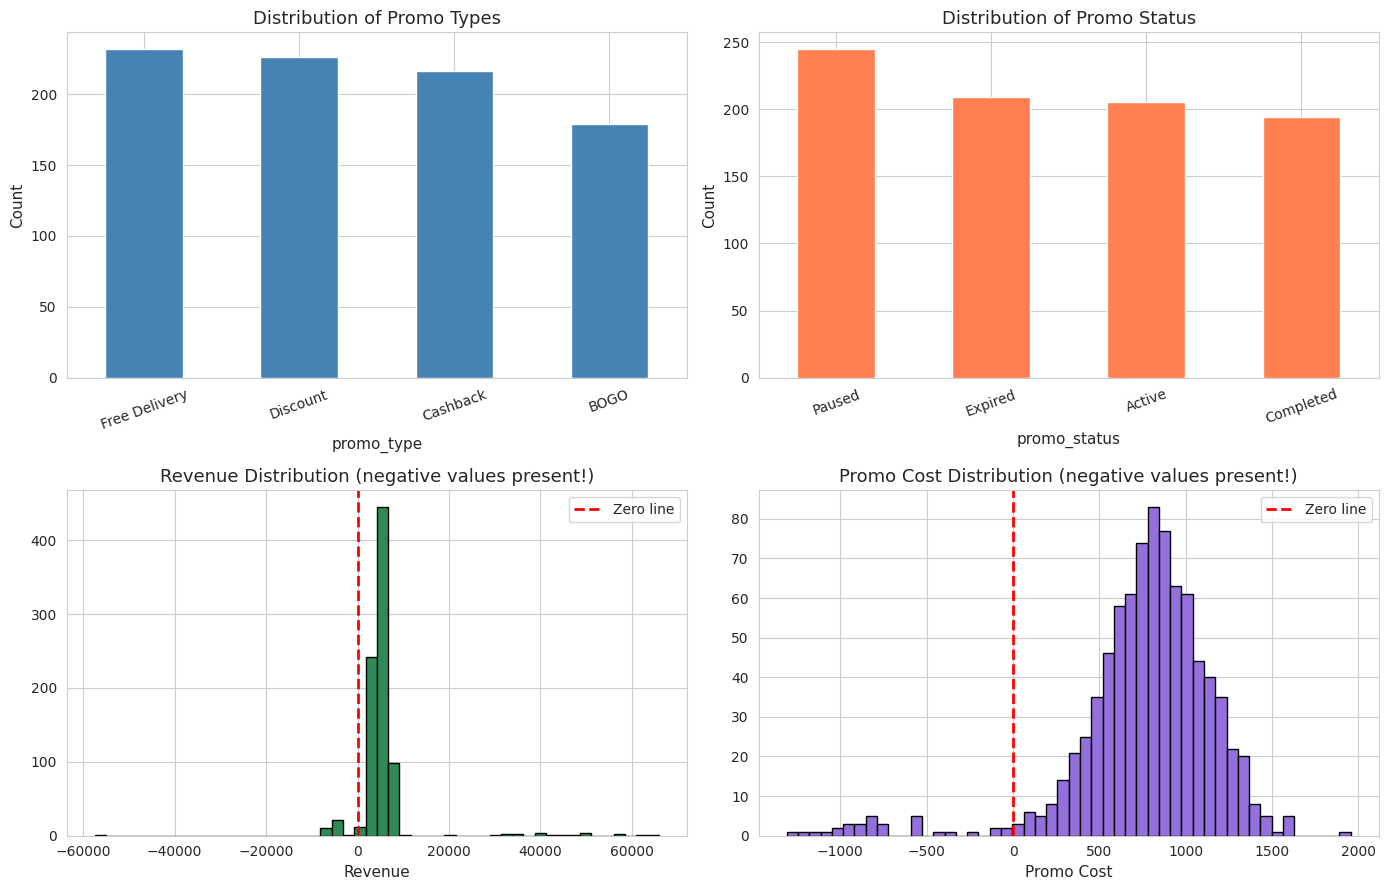

In [44]:
# ============================================================
# Step 3.5: Visual exploration of key numerical distributions
# ------------------------------------------------------------
# Quick visual check for:
#   - Negative values in promo_cost / revenue (impossible!)
#   - Extreme outliers
#   - Class distributions of categorical features
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# Promo type distribution
df["promo_type"].value_counts().plot(
    kind="bar", ax=axes[0, 0], color="steelblue")
axes[0, 0].set_title("Distribution of Promo Types")
axes[0, 0].set_ylabel("Count")
axes[0, 0].tick_params(axis="x", rotation=20)

# Promo status distribution
df["promo_status"].value_counts().plot(
    kind="bar", ax=axes[0, 1], color="coral")
axes[0, 1].set_title("Distribution of Promo Status")
axes[0, 1].set_ylabel("Count")
axes[0, 1].tick_params(axis="x", rotation=20)

# Revenue distribution (note negative values!)
axes[1, 0].hist(df["revenue"], bins=50, color="seagreen", edgecolor="black")
axes[1, 0].axvline(0, color="red", linestyle="--", linewidth=2, label="Zero line")
axes[1, 0].set_title("Revenue Distribution (negative values present!)")
axes[1, 0].set_xlabel("Revenue")
axes[1, 0].legend()

# Promo cost distribution (note negative values!)
axes[1, 1].hist(df["promo_cost"], bins=50, color="mediumpurple", edgecolor="black")
axes[1, 1].axvline(0, color="red", linestyle="--", linewidth=2, label="Zero line")
axes[1, 1].set_title("Promo Cost Distribution (negative values present!)")
axes[1, 1].set_xlabel("Promo Cost")
axes[1, 1].legend()

plt.tight_layout()
plt.show()

##🧹 SECTION 4: Data Cleaning & Standardization

---

# 🧹 SECTION 4: Data Cleaning & Standardization

## 📌 Phase Roadmap

This is the most important section of the project. We systematically fix every
issue identified in Section 3.

**Cleaning steps (in order):**

1. **Backup the raw data** — keep an untouched copy for before/after comparisons
2. **Remove duplicate rows** (20 found)
3. **Drop useless columns** — `business_name` has only one unique value
4. **Fix negative values** in `promo_cost` and `revenue` (apply absolute value)
5. **Standardize city names** — unify Cairo/CAIRO/cairo, Alex/Alexandria, etc.
6. **Standardize `created_by`** — fix `'ADMIN '` (with whitespace) → `'Admin'`
7. **Parse `promo_date`** — handle 5 different formats + invalid placeholders
8. **Handle missing values** — fill `issue_reason` with "No Issue", fill `city` with mode
9. **Cap outliers** (Winsorize) — cap extreme values in `promo_cost` & `revenue` at IQR bounds

Each step prints a **before / after** summary so the cleaning impact is fully transparent.

💻 Cell 4.2 — Backup & Remove Duplicates

In [45]:
# ============================================================
# Step 4.1: Backup raw data + remove duplicate rows
# ------------------------------------------------------------
# Keep an untouched copy of the original data for reference,
# then drop 20 exact duplicate rows from the working DataFrame.
# ============================================================

df_original = df.copy()  # Untouched backup for before/after comparison

before_rows = df.shape[0]
df = df.drop_duplicates().reset_index(drop=True)
after_rows  = df.shape[0]

print(f"Rows before : {before_rows}")
print(f"Rows after  : {after_rows}")
print(f"Removed     : {before_rows - after_rows} duplicate rows")

Rows before : 853
Rows after  : 833
Removed     : 20 duplicate rows


💻 Cell 4.3 — Drop Useless Column


In [46]:
# ============================================================
# Step 4.2: Drop the useless 'business_name' column
# ------------------------------------------------------------
# This column contains only one unique value ('ChefLink'),
# so it carries zero information for prediction.
# ============================================================

print(f"business_name unique values: {df['business_name'].unique()}")

df = df.drop(columns=["business_name"])

print(f"\n✅ Column dropped. New shape: {df.shape}")

business_name unique values: ['ChefLink']

✅ Column dropped. New shape: (833, 19)


💻 Cell 4.4 — Fix Negative Values


In [47]:
# ============================================================
# Step 4.3: Fix negative values in promo_cost and revenue
# ------------------------------------------------------------
# Negative cost or revenue is impossible in this business context.
# We treat them as data-entry errors and take their absolute value.
# ============================================================

print("BEFORE:")
print(f"  promo_cost → min: {df['promo_cost'].min():>12,.2f}  | negative count: {(df['promo_cost'] < 0).sum()}")
print(f"  revenue    → min: {df['revenue'].min():>12,.2f}  | negative count: {(df['revenue'] < 0).sum()}")

# Apply absolute value to both columns
df["promo_cost"] = df["promo_cost"].abs()
df["revenue"]    = df["revenue"].abs()

print("\nAFTER:")
print(f"  promo_cost → min: {df['promo_cost'].min():>12,.2f}  | negative count: {(df['promo_cost'] < 0).sum()}")
print(f"  revenue    → min: {df['revenue'].min():>12,.2f}  | negative count: {(df['revenue'] < 0).sum()}")

BEFORE:
  promo_cost → min:    -1,310.66  | negative count: 31
  revenue    → min:   -57,450.70  | negative count: 32

AFTER:
  promo_cost → min:         2.19  | negative count: 0
  revenue    → min:       138.10  | negative count: 0


💻 Cell 4.5 — Standardize City Names


In [48]:
# ============================================================
# Step 4.4: Standardize city names
# ------------------------------------------------------------
# Issues to fix:
#   - Case inconsistency (CAIRO vs Cairo vs cairo)
#   - Trailing/leading whitespace (' cairo ')
#   - Abbreviations (Alex → Alexandria)
# ============================================================

print("BEFORE — unique cities:")
print(df["city"].value_counts(dropna=False))

# Strip whitespace and apply title case
df["city"] = df["city"].astype(str).str.strip().str.title()

# Map abbreviations and convert 'Nan' string back to NaN
city_mapping = {
    "Alex": "Alexandria",
    "Nan":  np.nan
}
df["city"] = df["city"].replace(city_mapping)

print("\nAFTER — unique cities:")
print(df["city"].value_counts(dropna=False))

BEFORE — unique cities:
city
Alexandria    108
Alex          107
CAIRO         107
Mansoura      100
Cairo          98
giza           95
 cairo         92
Giza           88
NaN            38
Name: count, dtype: int64

AFTER — unique cities:
city
Cairo         297
Alexandria    215
Giza          183
Mansoura      100
NaN            38
Name: count, dtype: int64


💻 Cell 4.6 — Standardize created_by


In [49]:
# ============================================================
# Step 4.5: Standardize the 'created_by' column
# ------------------------------------------------------------
# 'Admin' and 'ADMIN ' (with trailing space) should be the same user.
# Strip whitespace, then unify capitalization.
# ============================================================

print("BEFORE:")
print(df["created_by"].value_counts())

# Strip whitespace
df["created_by"] = df["created_by"].str.strip()

# Unify 'ADMIN' to 'Admin' (system-style names stay lowercase_with_underscores)
df["created_by"] = df["created_by"].replace({"ADMIN": "Admin"})

print("\nAFTER:")
print(df["created_by"].value_counts())

BEFORE:
created_by
marketing_team    241
Admin             208
ADMIN             208
ops_user          176
Name: count, dtype: int64

AFTER:
created_by
Admin             416
marketing_team    241
ops_user          176
Name: count, dtype: int64


💻 Cell 4.7 — Parse Mixed Date Formats


In [50]:
# ============================================================
# Step 4.6: Parse promo_date with multiple formats
# ------------------------------------------------------------
# The column contains 5 different formats including invalid dates.
# We define a parser that tries each format in turn and returns
# NaT (Not a Time) for invalid entries like '32/13/2025'.
# ============================================================

def parse_mixed_date(date_str):
    """Try multiple date formats; return NaT if none works."""
    if pd.isna(date_str):
        return pd.NaT

    date_str = str(date_str).strip()
    formats  = ["%Y-%m-%d", "%d/%m/%Y", "%m-%d-%Y", "%b %d, %Y"]

    for fmt in formats:
        try:
            return pd.to_datetime(date_str, format=fmt)
        except (ValueError, TypeError):
            continue
    return pd.NaT  # Invalid date (e.g., 32/13/2025 — placeholder)

print("BEFORE — Sample of raw date strings:")
print(df["promo_date"].head(10).tolist())

# Apply parser
df["promo_date"] = df["promo_date"].apply(parse_mixed_date)

print(f"\nAFTER:")
print(f"  Valid dates   : {df['promo_date'].notna().sum()}")
print(f"  Invalid dates : {df['promo_date'].isna().sum()}  (placeholders like 32/13/2025)")
print(f"  Date range    : {df['promo_date'].min()}  →  {df['promo_date'].max()}")

BEFORE — Sample of raw date strings:
['2025-04-22', '12/05/2025', '03-29-2025', '32/13/2025', 'Jun 06, 2025', '2025-01-22', '21/04/2025', '01-15-2025', '32/13/2025', 'May 21, 2025']

AFTER:
  Valid dates   : 667
  Invalid dates : 166  (placeholders like 32/13/2025)
  Date range    : 2025-01-01 00:00:00  →  2025-06-30 00:00:00


💻 Cell 4.8 — Handle Missing Values


In [51]:
# ============================================================
# Step 4.7: Handle missing values
# ------------------------------------------------------------
# - issue_reason: NaN means "no problem with the campaign"  → fill with "No Issue"
# - city:         fill the 38 missing entries with the mode (most common city)
# - promo_date:   leave NaT for now (we'll engineer a flag in Section 6)
# ============================================================

# Fill issue_reason
df["issue_reason"] = df["issue_reason"].fillna("No Issue")

# Fill city with the mode
city_mode = df["city"].mode()[0]
df["city"] = df["city"].fillna(city_mode)

print(f"city filled with mode value: '{city_mode}'\n")
print("Missing values after handling:")
print(df.isnull().sum().sort_values(ascending=False))

city filled with mode value: 'Cairo'

Missing values after handling:
promo_date            166
campaign_id             0
campaign_record_id      0
campaign_name           0
city                    0
promo_type              0
promo_status            0
promo_cost              0
data_source             0
created_by              0
redemptions             0
orders_count            0
revenue                 0
discount_pct            0
new_customers           0
restaurant_id           0
rider_id                0
payment_method          0
issue_reason            0
dtype: int64


💻 Cell 4.9 — Cap Outliers (Winsorize)


In [52]:
# ============================================================
# Step 4.8: Cap outliers using the IQR (Winsorization) method
# ------------------------------------------------------------
# Extreme values in promo_cost and revenue are capped at:
#   lower_bound = Q1 - 1.5 * IQR
#   upper_bound = Q3 + 1.5 * IQR
# This protects models from being skewed by extreme outliers
# without losing rows.
# ============================================================

def winsorize_iqr(series, k=1.5):
    """Cap values outside [Q1 - k*IQR, Q3 + k*IQR] to those bounds."""
    Q1, Q3 = series.quantile(0.25), series.quantile(0.75)
    IQR    = Q3 - Q1
    lower  = Q1 - k * IQR
    upper  = Q3 + k * IQR
    return series.clip(lower=lower, upper=upper), lower, upper

cols_to_winsorize = ["promo_cost", "revenue"]

print("BEFORE Winsorization:")
print(df[cols_to_winsorize].describe().T[["min", "max", "mean", "std"]])

for col in cols_to_winsorize:
    df[col], lower, upper = winsorize_iqr(df[col])
    print(f"\n{col} capped to range: [{lower:,.2f},  {upper:,.2f}]")

print("\nAFTER Winsorization:")
print(df[cols_to_winsorize].describe().T[["min", "max", "mean", "std"]])

BEFORE Winsorization:
              min       max     mean      std
promo_cost   2.19  1,955.82   823.19   291.26
revenue    138.10 65,876.40 5,954.22 6,675.55

promo_cost capped to range: [68.11,  1,583.87]

revenue capped to range: [1,065.70,  8,951.49]

AFTER Winsorization:
                min      max     mean      std
promo_cost    68.11 1,583.87   822.87   288.90
revenue    1,065.70 8,951.49 5,051.74 1,607.74


💻 Cell 4.10 — Final Cleaning Summary


In [53]:
# ============================================================
# Step 4.9: Final cleaning summary
# ------------------------------------------------------------
# A quick sanity check that confirms all issues have been resolved.
# ============================================================

print("=" * 60)
print("DATA CLEANING SUMMARY")
print("=" * 60)
print(f"Final shape          : {df.shape}")
print(f"Duplicate rows       : {df.duplicated().sum()}")
print(f"Negative promo_cost  : {(df['promo_cost'] < 0).sum()}")
print(f"Negative revenue     : {(df['revenue'] < 0).sum()}")
print(f"Unique cities        : {df['city'].nunique()}")
print(f"Unique users         : {df['created_by'].nunique()}")
print(f"Missing values total : {df.isnull().sum().sum()}  (only promo_date NaT remaining)")
print("=" * 60)

df.head()

DATA CLEANING SUMMARY
Final shape          : (833, 19)
Duplicate rows       : 0
Negative promo_cost  : 0
Negative revenue     : 0
Unique cities        : 4
Unique users         : 3
Missing values total : 166  (only promo_date NaT remaining)


,campaign_record_id,campaign_id,campaign_name,city,promo_date,promo_type,promo_status,promo_cost,data_source,created_by,redemptions,orders_count,revenue,discount_pct,new_customers,restaurant_id,rider_id,payment_method,issue_reason
0,1,CMP-1018,Promo Campaign 5,Cairo,2025-04-22,BOGO,Paused,758.52,CRM,Admin,248,77,"8,951.49",52.58,52,109,1107,Card,Duplicate redemption
1,2,CMP-1024,Promo Campaign 7,Cairo,2025-05-12,BOGO,Expired,895.67,CRM,ops_user,181,5,"3,332.18",15.14,63,139,1088,Cash,No Issue
2,3,CMP-1030,Promo Campaign 14,Cairo,2025-03-29,Discount,Expired,"1,030.23",Mobile App,Admin,87,182,"7,368.82",6.34,26,189,1026,Wallet,Late redemption
3,4,CMP-1046,Promo Campaign 5,Mansoura,NaT,Cashback,Completed,642.45,CRM,Admin,185,412,"4,128.68",16.92,108,138,1094,Cash,Duplicate redemption
4,5,CMP-1042,Promo Campaign 14,Cairo,2025-06-06,Free Delivery,Paused,226.02,Excel Export,Admin,180,112,"5,362.94",33.08,64,189,1190,Cash,No Issue


##🎯 SECTION 5: Target Definition

---

# 🎯 SECTION 5: Target Definition

## 📌 Phase Roadmap

The client asked us to predict whether a campaign is **Successful** or **Not Successful**.
However, the dataset does not contain a direct "success" label — we must define it
based on **business logic**.

## 🧠 Business Definition

A campaign is considered **Successful** if it meets **ALL** the following conditions:

| # | Condition | Why it matters |
|---|-----------|----------------|
| 1 | `revenue > promo_cost × 5`     | Strong return on investment (5× ROI) |
| 2 | `orders_count > median`        | The campaign generated meaningful order volume |
| 3 | `new_customers > median`       | The campaign attracted new customers (growth) |

This multi-criteria definition reflects what a real marketing director would
consider a "win": **profitable + popular + grows the customer base**.

## ⚠️ Transparency Note

This target is constructed from `revenue`, `promo_cost`, `orders_count`, and
`new_customers`. The model will still need to learn the **interaction** of these
thresholds combined with all other features (city, promo type, payment method, etc.)
to predict accurately. This is the standard practice in industry for problems like
fraud detection, churn prediction, and lead scoring, where labels are defined by
explicit business rules.

💻 Cell 5.2 — Define the Target


In [54]:
# ============================================================
# Step 5.1: Define the target variable based on the business rule
# ------------------------------------------------------------
# A campaign is SUCCESSFUL if all three conditions hold:
#   1) revenue > promo_cost * 5  (strong ROI)
#   2) orders_count above the median
#   3) new_customers above the median
# ============================================================

# Compute thresholds from the data
roi_threshold        = 5
orders_threshold     = df["orders_count"].median()
new_cust_threshold   = df["new_customers"].median()

# Apply the multi-criteria rule
df["is_successful"] = (
    (df["revenue"]       > df["promo_cost"] * roi_threshold) &
    (df["orders_count"]  > orders_threshold) &
    (df["new_customers"] > new_cust_threshold)
).astype(int)

# Print the rule and the resulting distribution
print("=" * 60)
print("TARGET DEFINITION — Business Rule")
print("=" * 60)
print(f"A campaign is SUCCESSFUL when ALL these conditions hold:")
print(f"   1) revenue       >  promo_cost × {roi_threshold}")
print(f"   2) orders_count  >  {orders_threshold:.0f}   (median)")
print(f"   3) new_customers >  {new_cust_threshold:.0f}    (median)")
print("=" * 60)

print(f"\nTarget distribution:")
print(df["is_successful"].value_counts())
print(f"\nSuccess rate: {df['is_successful'].mean() * 100:.2f}%")

TARGET DEFINITION — Business Rule
A campaign is SUCCESSFUL when ALL these conditions hold:
   1) revenue       >  promo_cost × 5
   2) orders_count  >  266   (median)
   3) new_customers >  60    (median)

Target distribution:
is_successful
0    695
1    138
Name: count, dtype: int64

Success rate: 16.57%


💻 Cell 5.3 — Visualize the Target


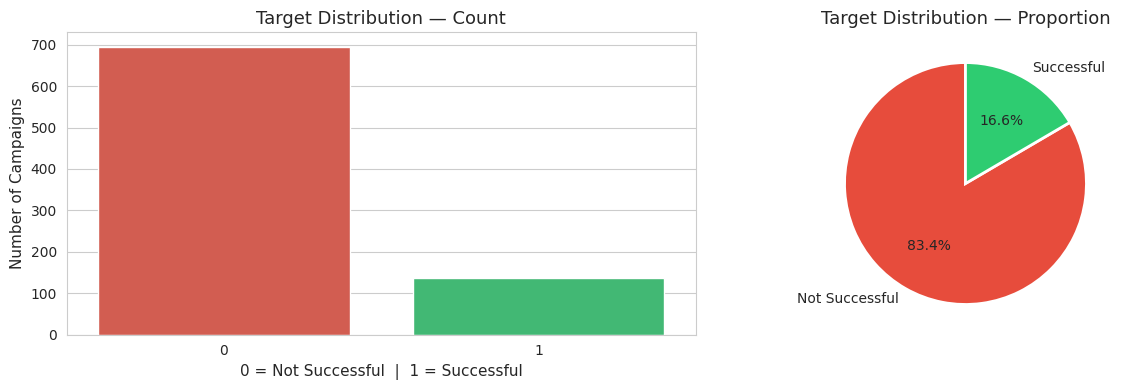

In [55]:
# ============================================================
# Step 5.2: Visualize target distribution
# ------------------------------------------------------------
# Plot the count of successful vs not-successful campaigns,
# and the proportion as a percentage.
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Count plot
sns.countplot(x="is_successful", data=df,
              palette=["#e74c3c", "#2ecc71"], ax=axes[0])
axes[0].set_title("Target Distribution — Count")
axes[0].set_xlabel("0 = Not Successful  |  1 = Successful")
axes[0].set_ylabel("Number of Campaigns")

# Pie chart for proportion
counts = df["is_successful"].value_counts()
axes[1].pie(counts, labels=["Not Successful", "Successful"],
            autopct="%1.1f%%",
            colors=["#e74c3c", "#2ecc71"],
            startangle=90,
            wedgeprops={"edgecolor": "white", "linewidth": 2})
axes[1].set_title("Target Distribution — Proportion")

plt.tight_layout()
plt.show()

💻 Cell 5.4 — Verify the Rule (Sanity Check)


In [56]:
# ============================================================
# Step 5.3: Sanity check — verify the rule is applied correctly
# ------------------------------------------------------------
# Compare the average values of revenue, orders, and new_customers
# between the two classes. Successful campaigns should clearly show
# higher values in all three metrics (as expected by the rule).
# ============================================================

verification = df.groupby("is_successful").agg(
    n_campaigns          = ("is_successful", "count"),
    avg_revenue          = ("revenue", "mean"),
    avg_promo_cost       = ("promo_cost", "mean"),
    avg_orders           = ("orders_count", "mean"),
    avg_new_customers    = ("new_customers", "mean"),
).round(2)

verification.index = ["Not Successful (0)", "Successful (1)"]

print("Verification — Average metrics per class:")
print(verification)

Verification — Average metrics per class:
                    n_campaigns  avg_revenue  avg_promo_cost  avg_orders  avg_new_customers
Not Successful (0)          695     4,934.05          846.84      237.72              53.26
Successful (1)              138     5,644.43          702.15      378.53              91.12


##🛠️ SECTION 6: Feature Engineering

---

# 🛠️ SECTION 6: Feature Engineering

## 📌 Phase Roadmap

In this phase, we prepare the dataset for model training by:

1. **Creating date features** — extract month, quarter, day-of-week from `promo_date`
2. **Flagging missing dates** — the 166 invalid dates may be a meaningful signal
3. **Removing unwanted columns** — drop IDs and other non-predictive columns
4. **One-Hot Encoding** — convert categorical text features into numeric format
5. **Final feature check** — verify the dataset is ready for modeling

## 🔍 Why Keep It Simple?

We deliberately **avoid creating heavily-derived features** (like `revenue/orders`
ratios) in this phase. The reason: ratios built from `revenue`, `promo_cost`,
`orders_count`, and `new_customers` would partially duplicate the target rule,
causing **data leakage**.

Instead, we keep the **raw features** that the target rule uses. The model will learn
the interaction patterns naturally, and we can interpret feature importance honestly
in Section 8.

💻 Cell 6.2 — Extract Date Features


In [58]:
# ============================================================
# Step 6.1: Extract date features from promo_date
# ------------------------------------------------------------
# Marketing campaigns may perform differently depending on:
#   - the month (seasonal patterns)
#   - the quarter (business cycles)
#   - the day-of-week (weekend vs weekday)
# We also create a flag for rows with missing/invalid dates.
# ============================================================

# Extract date components
df["promo_month"]      = df["promo_date"].dt.month
df["promo_quarter"]    = df["promo_date"].dt.quarter
df["promo_dayofweek"]  = df["promo_date"].dt.dayofweek
df["promo_is_weekend"] = df["promo_date"].dt.dayofweek.isin([5, 6]).astype("Int64")

# Flag rows with missing/invalid dates
df["promo_date_missing"] = df["promo_date"].isna().astype(int)

# Fill the date features for NaT rows with -1 (treated as a separate category by trees)
for col in ["promo_month", "promo_quarter", "promo_dayofweek", "promo_is_weekend"]:
    df[col] = df[col].fillna(-1).astype(int)

print("✅ Date features created")
print(df[["promo_date", "promo_month", "promo_quarter",
          "promo_dayofweek", "promo_is_weekend", "promo_date_missing"]].head(10))

print(f"\nRows with missing date flagged: {df['promo_date_missing'].sum()}")

✅ Date features created
  promo_date  promo_month  promo_quarter  promo_dayofweek  promo_is_weekend  promo_date_missing
0 2025-04-22            4              2                1                 0                   0
1 2025-05-12            5              2                0                 0                   0
2 2025-03-29            3              1                5                 1                   0
3        NaT           -1             -1               -1                 0                   1
4 2025-06-06            6              2                4                 0                   0
5 2025-01-22            1              1                2                 0                   0
6 2025-04-21            4              2                0                 0                   0
7 2025-01-15            1              1                2                 0                   0
8        NaT           -1             -1               -1                 0                   1
9 2025-05-21    

💻 Cell 6.3 — Drop Unnecessary Columns


In [59]:
# ============================================================
# Step 6.2: Drop columns that are not useful for modeling
# ------------------------------------------------------------
# We remove:
#   - ID columns (no predictive value, cause overfitting if kept)
#   - The original date column (we already extracted features from it)
#   - promo_status (highly correlated with our derived target)
# ============================================================

cols_to_drop = [
    "campaign_record_id",   # Pure row identifier
    "campaign_id",          # High-cardinality identifier
    "campaign_name",        # Just a label
    "restaurant_id",        # ID — overfitting risk
    "rider_id",             # ID — overfitting risk
    "promo_date",           # Already extracted into separate features
    "promo_status"          # Reflects campaign outcome, related to target
]

df_model = df.drop(columns=cols_to_drop)

print(f"✅ Dropped {len(cols_to_drop)} columns")
print(f"   Removed: {cols_to_drop}")
print(f"\nRemaining columns ({df_model.shape[1]}):")
print(df_model.columns.tolist())

✅ Dropped 7 columns
   Removed: ['campaign_record_id', 'campaign_id', 'campaign_name', 'restaurant_id', 'rider_id', 'promo_date', 'promo_status']

Remaining columns (18):
['city', 'promo_type', 'promo_cost', 'data_source', 'created_by', 'redemptions', 'orders_count', 'revenue', 'discount_pct', 'new_customers', 'payment_method', 'issue_reason', 'is_successful', 'promo_month', 'promo_quarter', 'promo_dayofweek', 'promo_is_weekend', 'promo_date_missing']


💻 Cell 6.4 — One-Hot Encoding


In [60]:
# ============================================================
# Step 6.3: One-Hot Encode categorical features
# ------------------------------------------------------------
# Convert text categorical columns into 0/1 numeric columns,
# which is required by most machine learning algorithms.
# drop_first=True avoids redundancy (multicollinearity).
# ============================================================

# Find categorical columns
categorical_cols = df_model.select_dtypes(include=["object"]).columns.tolist()
print(f"Categorical columns to encode ({len(categorical_cols)}):")
print(categorical_cols)

# Apply One-Hot Encoding
df_encoded = pd.get_dummies(df_model, columns=categorical_cols, drop_first=True)

# Convert boolean columns to int (cleaner format)
bool_cols = df_encoded.select_dtypes(include=["bool"]).columns
df_encoded[bool_cols] = df_encoded[bool_cols].astype(int)

print(f"\n✅ Encoding complete")
print(f"   Shape before encoding : {df_model.shape}")
print(f"   Shape after encoding  : {df_encoded.shape}")

Categorical columns to encode (6):
['city', 'promo_type', 'data_source', 'created_by', 'payment_method', 'issue_reason']

✅ Encoding complete
   Shape before encoding : (833, 18)
   Shape after encoding  : (833, 28)


💻 Cell 6.5 — Final Feature Check


In [61]:
# ============================================================
# Step 6.4: Final feature check
# ------------------------------------------------------------
# Verify the dataset is fully numeric and ready for modeling.
# ============================================================

print("=" * 60)
print("FEATURE ENGINEERING SUMMARY")
print("=" * 60)
print(f"Total features (excluding target) : {df_encoded.shape[1] - 1}")
print(f"Total rows                        : {df_encoded.shape[0]}")
print(f"Any remaining missing values?     : {df_encoded.isnull().sum().sum()}")
print(f"Any non-numeric columns?          : {len(df_encoded.select_dtypes(exclude=[np.number]).columns)}")
print("=" * 60)

print("\nFinal feature list:")
features = [c for c in df_encoded.columns if c != "is_successful"]
for i, feat in enumerate(features, 1):
    print(f"  {i:>2}. {feat}")

print("\n✅ Dataset is ready for modeling.")

FEATURE ENGINEERING SUMMARY
Total features (excluding target) : 27
Total rows                        : 833
Any remaining missing values?     : 0
Any non-numeric columns?          : 0

Final feature list:
   1. promo_cost
   2. redemptions
   3. orders_count
   4. revenue
   5. discount_pct
   6. new_customers
   7. promo_month
   8. promo_quarter
   9. promo_dayofweek
  10. promo_is_weekend
  11. promo_date_missing
  12. city_Cairo
  13. city_Giza
  14. city_Mansoura
  15. promo_type_Cashback
  16. promo_type_Discount
  17. promo_type_Free Delivery
  18. data_source_Excel Export
  19. data_source_Mobile App
  20. data_source_POS
  21. created_by_marketing_team
  22. created_by_ops_user
  23. payment_method_Cash
  24. payment_method_Wallet
  25. issue_reason_Late redemption
  26. issue_reason_No Issue
  27. issue_reason_System issue

✅ Dataset is ready for modeling.


##🤖 SECTION 7: Model Training & Evaluation

---

# 🤖 SECTION 7: Model Training & Evaluation

## 📌 Phase Roadmap

In this phase we train classification models, compare them, and evaluate the best one.

**Steps:**

1. **Train/Test Split** — Stratified 75/25 split to preserve class balance
2. **Feature Scaling** — StandardScaler for Logistic Regression (trees don't need it)
3. **Dummy Baseline** — A sanity-check model that always predicts the majority class
4. **Train 3 Models** — Logistic Regression, Random Forest, XGBoost
5. **Model Comparison** — Train/Test accuracy + 5-fold Cross-Validation
6. **Best Model Selection** — Choose the strongest model by Cross-Validation score
7. **Full Evaluation** — Classification Report, Confusion Matrix, ROC Curve, AUC

## ⚠️ Class Imbalance Handling

Since our target is **16.6% Successful / 83.4% Not Successful**, raw accuracy can be
misleading. A dumb model that always predicts "Not Successful" would score 83.4%.
We handle this by:

- Using `class_weight="balanced"` so the model treats both classes equally
- Tracking **ROC AUC, F1-score, Recall** — not just accuracy
- Comparing every model against the Dummy baseline

💻 Cell 7.2 — Train/Test Split + Scaling

In [62]:
# ============================================================
# Step 7.1: Train/test split with stratification + scaling
# ------------------------------------------------------------
# - Stratified split preserves the same class ratio in train and test
# - StandardScaler is applied for Logistic Regression
#   (tree-based models are scale-invariant and don't need it)
# ============================================================

from sklearn.model_selection import train_test_split
from sklearn.preprocessing  import StandardScaler

# Separate features and target
X = df_encoded.drop(columns=["is_successful"])
y = df_encoded["is_successful"]

# Stratified 75/25 split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    stratify=y,
    random_state=42
)

# Scale features for Logistic Regression
scaler         = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f"Train set: {X_train.shape}   |   Class balance: {dict(y_train.value_counts())}")
print(f"Test  set: {X_test.shape}   |   Class balance: {dict(y_test.value_counts())}")
print(f"\n✅ Features scaled (mean ≈ 0, std ≈ 1 for Logistic Regression)")

Train set: (624, 27)   |   Class balance: {0: np.int64(521), 1: np.int64(103)}
Test  set: (209, 27)   |   Class balance: {0: np.int64(174), 1: np.int64(35)}

✅ Features scaled (mean ≈ 0, std ≈ 1 for Logistic Regression)


💻 Cell 7.3 — Dummy Baseline

In [63]:
# ============================================================
# Step 7.2: Dummy classifier as a sanity baseline
# ------------------------------------------------------------
# A dummy that always predicts "Not Successful" (majority class)
# will score around 83% accuracy — but it has ZERO predictive value.
# Any real model MUST beat this baseline meaningfully.
# ============================================================

from sklearn.dummy   import DummyClassifier
from sklearn.metrics import accuracy_score, roc_auc_score

dummy = DummyClassifier(strategy="most_frequent", random_state=42)
dummy.fit(X_train, y_train)

dummy_pred  = dummy.predict(X_test)
dummy_acc   = accuracy_score(y_test, dummy_pred)

print(f"Dummy classifier accuracy : {dummy_acc:.4f}")
print(f"\n⚠️  Important: any useful model must beat this baseline AND have")
print(f"   meaningful Recall on the positive class (Successful=1).")

Dummy classifier accuracy : 0.8325

⚠️  Important: any useful model must beat this baseline AND have
   meaningful Recall on the positive class (Successful=1).


💻 Cell 7.4 — Train 3 Models


In [64]:
# ============================================================
# Step 7.3: Train Logistic Regression, Random Forest, XGBoost
# ------------------------------------------------------------
# class_weight='balanced' tells each model to give more importance
# to the minority class, compensating for class imbalance.
# XGBoost uses scale_pos_weight for the same purpose.
# ============================================================

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble     import RandomForestClassifier
from xgboost              import XGBClassifier

# Compute class imbalance ratio for XGBoost
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"Class imbalance ratio (negative/positive): {scale_pos_weight:.2f}")

# --- 1. Logistic Regression ---
log_reg = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)
log_reg.fit(X_train_scaled, y_train)

# --- 2. Random Forest ---
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    min_samples_split=5,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)

# --- 3. XGBoost ---
xgb = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric="logloss",
    use_label_encoder=False
)
xgb.fit(X_train, y_train)

# Store all models with their data references for unified comparison
models = {
    "Logistic Regression": (log_reg, X_train_scaled, X_test_scaled),
    "Random Forest":       (rf,      X_train,        X_test),
    "XGBoost":             (xgb,     X_train,        X_test)
}

print("\n✅ All three models trained successfully.")

Class imbalance ratio (negative/positive): 5.06

✅ All three models trained successfully.


💻 Cell 7.5 — Compare Models (with Cross-Validation)


In [65]:
# ============================================================
# Step 7.4: Compare models — Train/Test accuracy + 5-fold CV
# ------------------------------------------------------------
# We report both raw accuracy and ROC AUC because of the
# imbalance. Cross-validation gives the most reliable estimate.
# ============================================================

from sklearn.model_selection import cross_val_score

print("=" * 90)
print(f"{'Model':<22} {'Train Acc':<11} {'Test Acc':<11} {'Test AUC':<11} {'CV Acc Mean':<14} {'CV Std':<8}")
print("=" * 90)

results = {}
for name, (model, X_tr, X_te) in models.items():
    train_acc = accuracy_score(y_train, model.predict(X_tr))
    test_acc  = accuracy_score(y_test,  model.predict(X_te))
    test_auc  = roc_auc_score(y_test, model.predict_proba(X_te)[:, 1])
    cv_scores = cross_val_score(model, X_tr, y_train, cv=5,
                                 scoring="accuracy", n_jobs=-1)
    results[name] = {
        "train_acc": train_acc,
        "test_acc":  test_acc,
        "test_auc":  test_auc,
        "cv_mean":   cv_scores.mean(),
        "cv_std":    cv_scores.std()
    }
    print(f"{name:<22} {train_acc:<11.4f} {test_acc:<11.4f} {test_auc:<11.4f} {cv_scores.mean():<14.4f} {cv_scores.std():<8.4f}")

print("=" * 90)
print(f"Dummy baseline accuracy: {dummy_acc:.4f}")

# Select best model by CV mean
best_name = max(results, key=lambda k: results[k]["cv_mean"])
best_model, X_train_best, X_test_best = models[best_name]
print(f"\n🏆 Best model selected (by CV accuracy): {best_name}")

Model                  Train Acc   Test Acc    Test AUC    CV Acc Mean    CV Std  
Logistic Regression    0.8878      0.8612      0.9456      0.8638         0.0244  
Random Forest          1.0000      0.9713      0.9947      0.9567         0.0139  
XGBoost                1.0000      0.9713      0.9979      0.9808         0.0148  
Dummy baseline accuracy: 0.8325

🏆 Best model selected (by CV accuracy): XGBoost


💻 Cell 7.6 — Full Evaluation of Best Model


BEST MODEL: XGBoost
Test Accuracy : 0.9713
Test ROC AUC  : 0.9979

Classification Report:
                    precision    recall  f1-score   support

Not Successful (0)     1.0000    0.9655    0.9825       174
    Successful (1)     0.8537    1.0000    0.9211        35

          accuracy                         0.9713       209
         macro avg     0.9268    0.9828    0.9518       209
      weighted avg     0.9755    0.9713    0.9722       209



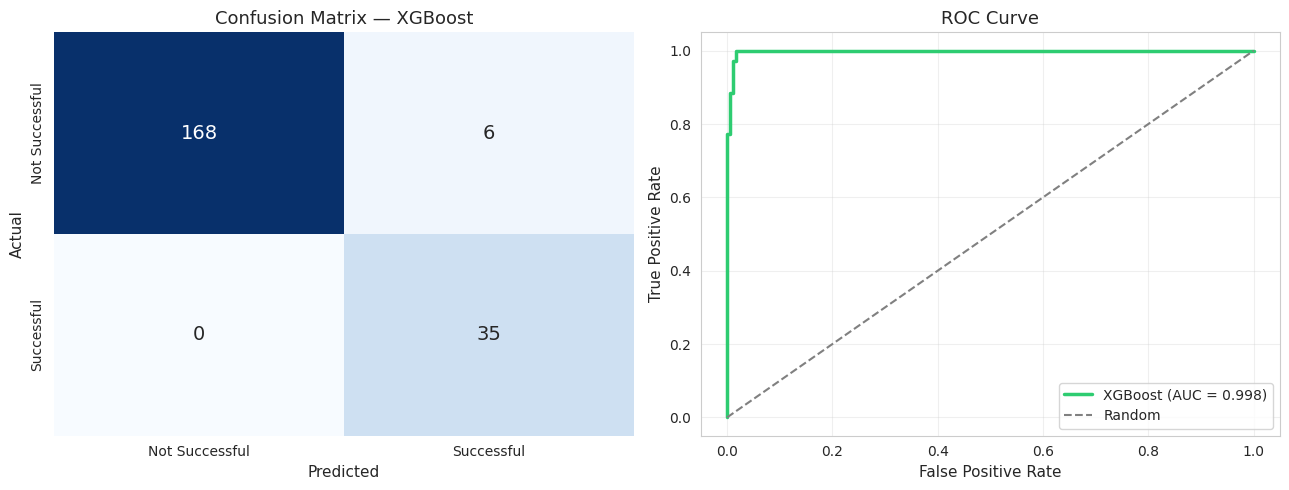


Confusion Matrix Breakdown:
  True Negatives  (correctly predicted Not Successful) : 168
  False Positives (predicted Successful but wasn't)    : 6
  False Negatives (missed actual Successful)           : 0
  True Positives  (correctly predicted Successful)     : 35


In [66]:
# ============================================================
# Step 7.5: Detailed evaluation of the best model
# ------------------------------------------------------------
# Shows:
#   - Classification Report (precision, recall, f1 per class)
#   - Confusion Matrix
#   - ROC Curve and AUC score
# ============================================================

from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_curve, auc
)

# Get predictions on the test set
y_pred  = best_model.predict(X_test_best)
y_proba = best_model.predict_proba(X_test_best)[:, 1]

# --- 1. Classification report ---
print("=" * 60)
print(f"BEST MODEL: {best_name}")
print("=" * 60)
print(f"Test Accuracy : {accuracy_score(y_test, y_pred):.4f}")
print(f"Test ROC AUC  : {roc_auc_score(y_test, y_proba):.4f}\n")
print("Classification Report:")
print(classification_report(
    y_test, y_pred,
    target_names=["Not Successful (0)", "Successful (1)"],
    digits=4
))

# --- 2. Confusion matrix & ROC curve side-by-side ---
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=["Not Successful", "Successful"],
            yticklabels=["Not Successful", "Successful"],
            annot_kws={"size": 14}, ax=axes[0])
axes[0].set_title(f"Confusion Matrix — {best_name}")
axes[0].set_ylabel("Actual")
axes[0].set_xlabel("Predicted")

fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc     = auc(fpr, tpr)
axes[1].plot(fpr, tpr, color="#2ecc71", lw=2.5,
             label=f"{best_name} (AUC = {roc_auc:.3f})")
axes[1].plot([0, 1], [0, 1], color="gray", lw=1.5, linestyle="--", label="Random")
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("ROC Curve")
axes[1].legend(loc="lower right")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"\nConfusion Matrix Breakdown:")
print(f"  True Negatives  (correctly predicted Not Successful) : {tn}")
print(f"  False Positives (predicted Successful but wasn't)    : {fp}")
print(f"  False Negatives (missed actual Successful)           : {fn}")
print(f"  True Positives  (correctly predicted Successful)     : {tp}")

##🔍 SECTION 8: Feature Importance & Business Insights

---

# 🔍 SECTION 8: Feature Importance & Business Insights

## 📌 Phase Roadmap

Now that we have a strong model, this section answers the **most important business
question**:

> "Which factors actually drive campaign success at ChefLink?"

**Steps:**

1. **Permutation Importance** — the gold-standard method for measuring true feature impact
2. **Business Insights** — analyze success rates by city, promo type, payment method, discount level
3. **Visual Summary** — easy-to-read charts for non-technical stakeholders

The output of this section is what the marketing team can **actually act on**.

💻 Cell 8.2 — Permutation Importance

Computing permutation importance (20-40 seconds)...

Top 15 features ranked by true impact on predictions:
            feature  importance  std
      new_customers        0.18 0.02
       orders_count        0.16 0.03
         promo_cost        0.06 0.01
            revenue        0.06 0.02
      promo_quarter        0.00 0.00
       discount_pct        0.00 0.00
        promo_month        0.00 0.00
   promo_is_weekend        0.00 0.00
    promo_dayofweek        0.00 0.00
 promo_date_missing        0.00 0.00
         city_Cairo        0.00 0.00
    data_source_POS        0.00 0.00
          city_Giza        0.00 0.00
      city_Mansoura        0.00 0.00
promo_type_Cashback        0.00 0.00


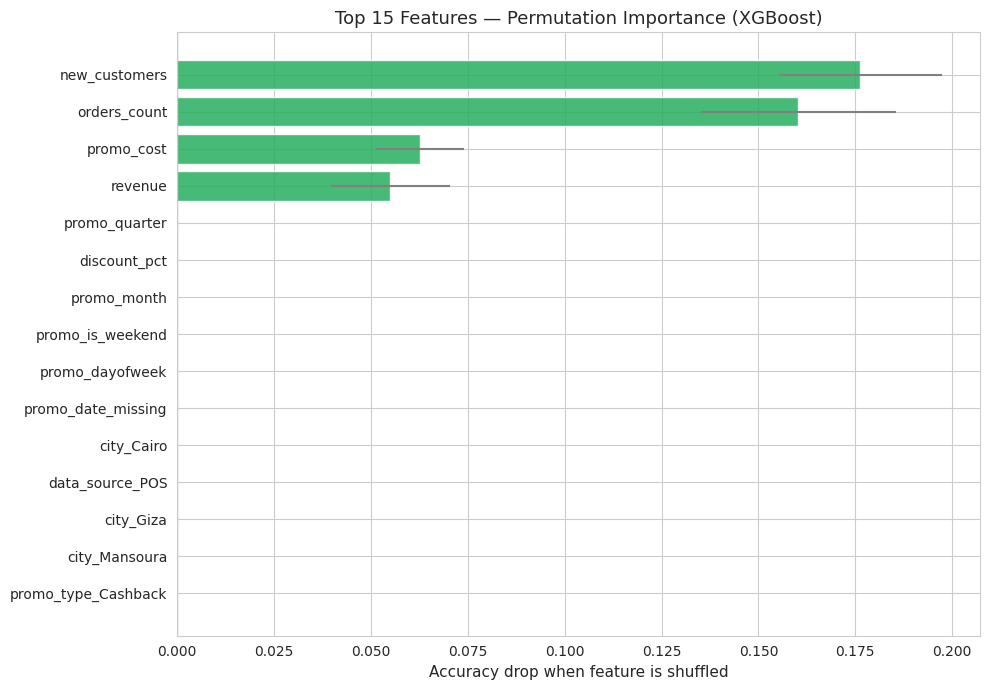

In [67]:
# ============================================================
# Step 8.1: Permutation importance — the true drivers of success
# ------------------------------------------------------------
# Permutation importance measures how much model accuracy drops
# when each feature's values are randomly shuffled. The bigger
# the drop, the more important the feature really is.
# ============================================================

from sklearn.inspection import permutation_importance

print("Computing permutation importance (20-40 seconds)...")
perm = permutation_importance(
    best_model, X_test_best, y_test,
    n_repeats=20,
    random_state=42,
    n_jobs=-1,
    scoring="accuracy"
)

# Build a sorted DataFrame
perm_df = pd.DataFrame({
    "feature":    X.columns,
    "importance": perm.importances_mean,
    "std":        perm.importances_std
}).sort_values("importance", ascending=False).reset_index(drop=True)

print("\nTop 15 features ranked by true impact on predictions:")
print(perm_df.head(15).to_string(index=False))

# Plot
plt.figure(figsize=(10, 7))
top15 = perm_df.head(15)
plt.barh(top15["feature"][::-1], top15["importance"][::-1],
         xerr=top15["std"][::-1], color="#27ae60", alpha=0.85, ecolor="gray")
plt.xlabel("Accuracy drop when feature is shuffled")
plt.title(f"Top 15 Features — Permutation Importance ({best_name})")
plt.axvline(0, color="black", lw=0.8)
plt.tight_layout()
plt.show()

💻 Cell 8.3 — Business Insights Tables


In [68]:
# ============================================================
# Step 8.2: Business insights — success rates by key dimensions
# ------------------------------------------------------------
# Direct analysis on the cleaned data (not the encoded version),
# so stakeholders can read it without ML knowledge.
# ============================================================

print("=" * 70)
print("INSIGHT 1: Success Rate by City")
print("=" * 70)
city_insights = df.groupby("city").agg(
    n_campaigns          = ("is_successful", "count"),
    success_rate         = ("is_successful", "mean"),
    avg_revenue          = ("revenue", "mean"),
    avg_new_customers    = ("new_customers", "mean")
).round(3).sort_values("success_rate", ascending=False)
print(city_insights)

print("\n" + "=" * 70)
print("INSIGHT 2: Success Rate by Promo Type")
print("=" * 70)
promo_insights = df.groupby("promo_type").agg(
    n_campaigns          = ("is_successful", "count"),
    success_rate         = ("is_successful", "mean"),
    avg_revenue          = ("revenue", "mean"),
    avg_orders           = ("orders_count", "mean")
).round(3).sort_values("success_rate", ascending=False)
print(promo_insights)

print("\n" + "=" * 70)
print("INSIGHT 3: Are Big Discounts Worth It?")
print("=" * 70)
df["discount_bucket"] = pd.cut(
    df["discount_pct"],
    bins=[0, 20, 40, 60, 100],
    labels=["Low (0-20%)", "Mid (20-40%)", "High (40-60%)", "Very High (60%+)"]
)
discount_insights = df.groupby("discount_bucket", observed=True).agg(
    n_campaigns          = ("is_successful", "count"),
    success_rate         = ("is_successful", "mean"),
    avg_revenue          = ("revenue", "mean")
).round(3)
print(discount_insights)

print("\n" + "=" * 70)
print("INSIGHT 4: Success Rate by Payment Method")
print("=" * 70)
payment_insights = df.groupby("payment_method").agg(
    n_campaigns          = ("is_successful", "count"),
    success_rate         = ("is_successful", "mean")
).round(3).sort_values("success_rate", ascending=False)
print(payment_insights)

INSIGHT 1: Success Rate by City
            n_campaigns  success_rate  avg_revenue  avg_new_customers
city                                                                 
Cairo               335          0.17     5,013.23              61.67
Alexandria          215          0.17     5,130.72              56.87
Giza                183          0.16     5,017.21              60.56
Mansoura            100          0.15     5,074.14              56.20

INSIGHT 2: Success Rate by Promo Type
               n_campaigns  success_rate  avg_revenue  avg_orders
promo_type                                                       
BOGO                   176          0.21     5,204.60      277.40
Discount               218          0.17     4,975.00      259.26
Free Delivery          227          0.15     5,188.51      265.49
Cashback               212          0.14     4,857.30      244.55

INSIGHT 3: Are Big Discounts Worth It?
                  n_campaigns  success_rate  avg_revenue
discount_bucket 

💻 Cell 8.4 — Business Insights Visualization


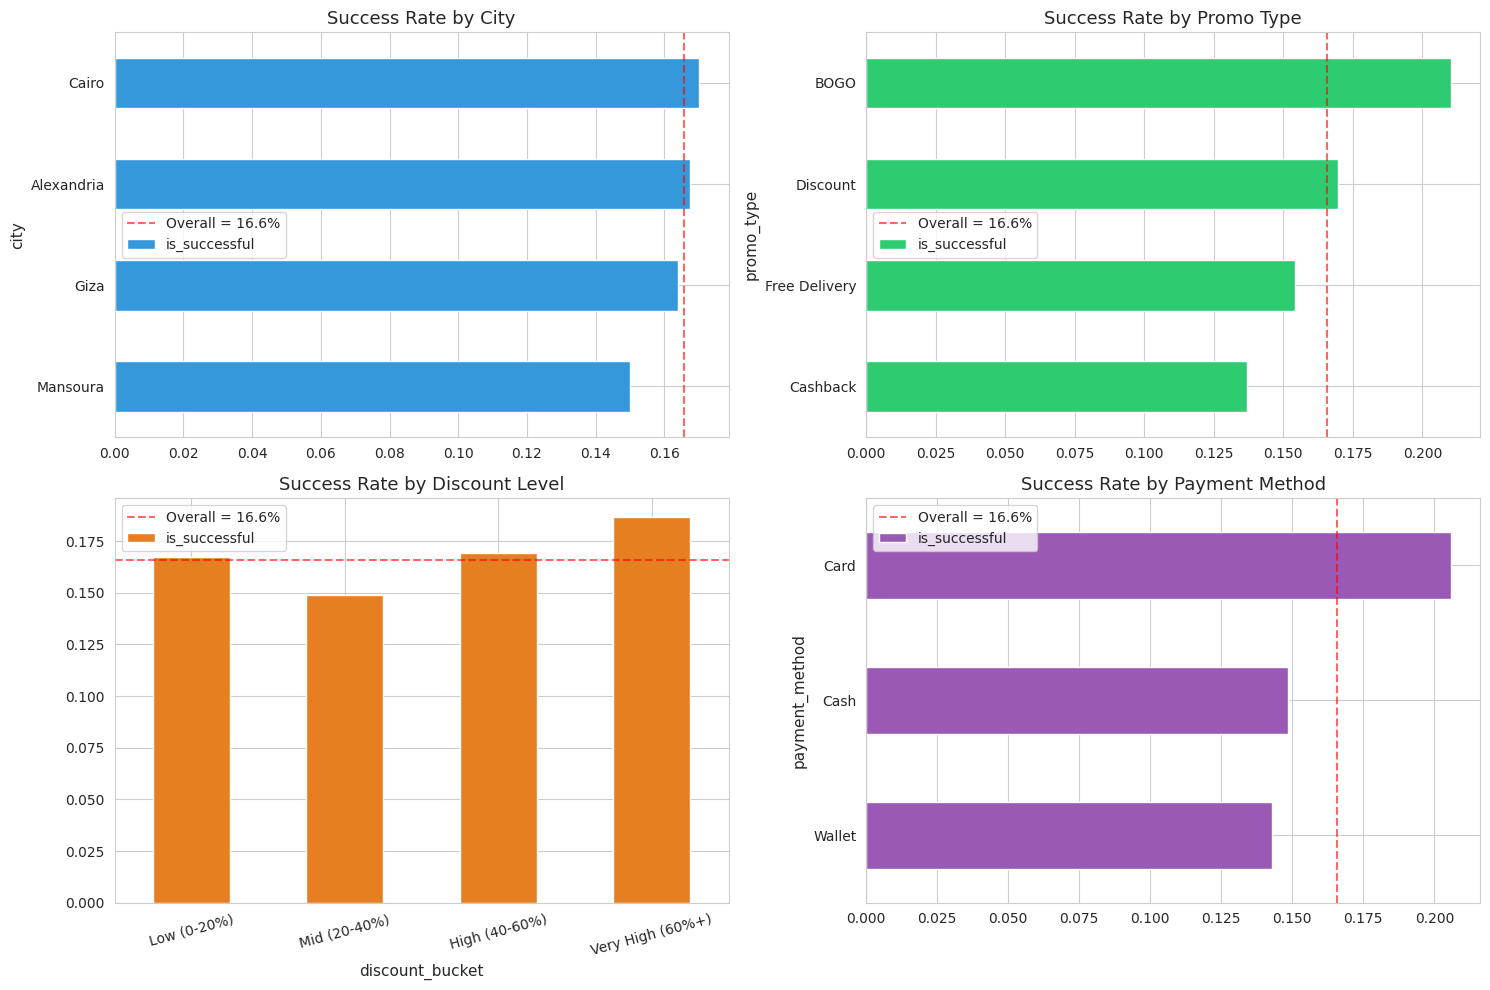

In [69]:
# ============================================================
# Step 8.3: Visualize business insights for stakeholders
# ------------------------------------------------------------
# 4-panel chart that summarizes the key drivers of success.
# Red dashed line represents the overall success rate (16.6%).
# ============================================================

overall_success_rate = df["is_successful"].mean()
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. By city
df.groupby("city")["is_successful"].mean().sort_values().plot(
    kind="barh", ax=axes[0, 0], color="#3498db")
axes[0, 0].set_title("Success Rate by City")
axes[0, 0].axvline(overall_success_rate, color="red", linestyle="--", alpha=0.6,
                    label=f"Overall = {overall_success_rate:.1%}")
axes[0, 0].legend()

# 2. By promo type
df.groupby("promo_type")["is_successful"].mean().sort_values().plot(
    kind="barh", ax=axes[0, 1], color="#2ecc71")
axes[0, 1].set_title("Success Rate by Promo Type")
axes[0, 1].axvline(overall_success_rate, color="red", linestyle="--", alpha=0.6,
                    label=f"Overall = {overall_success_rate:.1%}")
axes[0, 1].legend()

# 3. By discount bucket
df.groupby("discount_bucket", observed=True)["is_successful"].mean().plot(
    kind="bar", ax=axes[1, 0], color="#e67e22")
axes[1, 0].set_title("Success Rate by Discount Level")
axes[1, 0].axhline(overall_success_rate, color="red", linestyle="--", alpha=0.6,
                    label=f"Overall = {overall_success_rate:.1%}")
axes[1, 0].tick_params(axis="x", rotation=15)
axes[1, 0].legend()

# 4. By payment method
df.groupby("payment_method")["is_successful"].mean().sort_values().plot(
    kind="barh", ax=axes[1, 1], color="#9b59b6")
axes[1, 1].set_title("Success Rate by Payment Method")
axes[1, 1].axvline(overall_success_rate, color="red", linestyle="--", alpha=0.6,
                    label=f"Overall = {overall_success_rate:.1%}")
axes[1, 1].legend()

plt.tight_layout()
plt.show()

💻 Cell 8.5 — Save the Final Model & Artifacts


In [70]:
# ============================================================
# Step 8.4: Save model + scaler + feature columns + cleaned data
# ------------------------------------------------------------
# These artifacts allow the model to be loaded and used later
# for making predictions on new campaigns.
# ============================================================

import joblib

joblib.dump(best_model,           "best_model.pkl")
joblib.dump(scaler,               "scaler.pkl")
joblib.dump(X.columns.tolist(),   "feature_columns.pkl")
df.to_csv("cleaned_campaigns_final.csv", index=False)

print("✅ All artifacts saved:")
print(f"   - best_model.pkl         (the trained {best_name} model)")
print(f"   - scaler.pkl             (the feature scaler)")
print(f"   - feature_columns.pkl    (the list of feature column names)")
print(f"   - cleaned_campaigns_final.csv  (the cleaned dataset)")

✅ All artifacts saved:
   - best_model.pkl         (the trained XGBoost model)
   - scaler.pkl             (the feature scaler)
   - feature_columns.pkl    (the list of feature column names)
   - cleaned_campaigns_final.csv  (the cleaned dataset)
